## CLIP Image To Text 구현

OpenAI CLIP  설치

In [ ]:
# !pip install torchvision
# !pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

사전학습된 CLIP 모델 로딩

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [3]:
import os
import clip
import torch
from torchvision.datasets import CIFAR100

# 디바이스 설정
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

model, preprocess = clip.load('ViT-B/32', device)


cuda


데이터셋 로딩

Class ID: 78, Class Name: snake


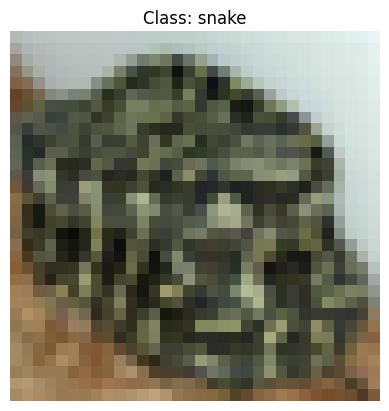

In [ ]:
# CIFAR-100 데이터셋 로드 (테스트셋)
cifar100 = CIFAR100(root=os.path.expanduser("~/.cache"), download=True, train=False)

# 특정 이미지 선택 (예: 인덱스 3637)
image, class_id = cifar100[3637]
image_input = preprocess(image).unsqueeze(0).to(device)

print(f"Class ID: {class_id}, Class Name: {cifar100.classes[class_id]}")

import matplotlib.pyplot as plt

# 이미지와 텍스트 특징 추출
plt.imshow(image)
plt.axis('off')
plt.title(f"Class: {cifar100.classes[class_id]}")
plt.show()


데이터 유사도 테스트

In [ ]:
# 테스트를 위해 CiFAR-100의 한 이미지와 모든 클래스 레이블을 사용
text_inputs = torch.cat([clip.tokenize(f"a photo of a {c}") for c in cifar100.classes]).to(device)
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

# 테스트 이미지와 모든 텍스트 레이블 간의 유사도 계산
image_features /= image_features.norm(dim=-1, keepdim=True)
text_features /= text_features.norm(dim=-1, keepdim=True)
similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
values, indices = similarity[0].topk(5) # 가장 테스트이미지와 유사한 5개 텍스트 레이블 선택

# 결과 출력
print("\nTop predictions:\n")
for value, index in zip(values, indices):
    print(f"{cifar100.classes[index]:>16s}: {100 * value.item():.2f}%")



Top predictions:

           snake: 65.23%
          turtle: 12.45%
    sweet_pepper: 3.86%
          lizard: 1.88%
       crocodile: 1.74%


테스트 이미지(Zeroshot)로 CLIP 모델 예측 예제

In [6]:
import torch
import clip
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)


In [ ]:
from google.colab import files
data_to_load = files.upload()

In [ ]:
file = Image.open("./cat3.jpg")  # Zeroshot 예제 이미지 경로 (Unseen 이미지)
image = preprocess(file).unsqueeze(0).to(device)
labels = ["big dog", "siamese cat", "orange tabby cat"]
text = clip.tokenize(labels).to(device)

with torch.no_grad():
    image_features = model.encode_image(image) # 이미지 특징 추출
    text_features = model.encode_text(text) # 텍스트 특징 추출

    logits_per_image, logits_per_text = model(image, text) # 이미지-텍스트 유사도 계산
    probs = logits_per_image.softmax(dim=-1).cpu().numpy() # 리턴된 logit을 softmax를 통해 확률값으로 변환

probs

array([[1.550e-06, 3.006e-04, 9.995e-01]], dtype=float16)

In [8]:
print("Label probs:")  # prints: [[0.9927937  0.00421068 0.00299572]]
for i in range(len(probs[0])):
  print(f'{labels[i]}: {probs[0][i]}')


Label probs:
big dog: 1.5497207641601562e-06
siamese cat: 0.0003006458282470703
orange tabby cat: 0.99951171875


이미지와 유사한 텍스트 키워드 계산 및 이미지 묘사

In [9]:
# 키워드 조합으로 descriptions 생성
descriptions = ["cat", "dog", "kitten", "orange cat", "white cat", "gray cat", "brown cat", 
                "cat sitting", "cat lying", "dog sitting", "cat indoors", "cat outdoors"]

text = clip.tokenize(descriptions).to(device)

with torch.no_grad():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)
    
    # 유사도 계산
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    
    # 상위 5개 결과
    values, indices = similarity[0].topk(5)

descriptions_text = [descriptions[i] for i in indices]
print(descriptions_text)


['orange cat', 'brown cat', 'cat indoors', 'cat', 'cat lying']


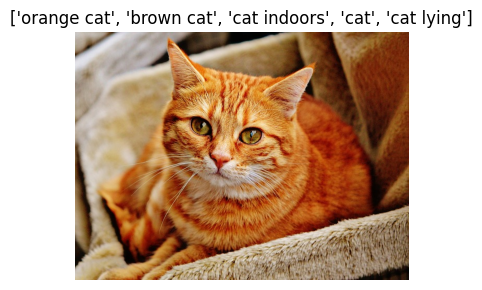

In [11]:
# 이미지 표시
plt.figure(figsize=(4, 3))
plt.imshow(file)
plt.axis('off')
plt.title(f"{descriptions_text}")
plt.tight_layout()
plt.show()
